# implementing get_ensemble_spread()

- we only have from 2017-01-01
- went from 21 -> 31 members on October 2020

In [ ]:
#testing Herbie dataset

from herbie import Herbie

H = Herbie('2017-01-01 00:00', model="gefs", member=0, fxx=24,save_dir='/tmp')
# only add save_dir in the final vers. for the debugging stage it should be fine
ds = H.xarray("TMP:2 m")
print(ds)

✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
<xarray.Dataset> Size: 265kB
Dimensions:              (latitude: 181, longitude: 360)
Coordinates:
  * latitude             (latitude) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * longitude            (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number               int64 8B 0
    time                 datetime64[ns] 8B 2017-01-01
    step                 timedelta64[ns] 8B 1 days
    heightAboveGround    float64 8B 2.0
    valid_time           datetime64[ns] 8B 2017-01-02
    gribfile_projection  object 8B None
Data variables:
    t2m                  (latitude, longitude) float32 261kB 248.6 ... 247.5
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:

In [7]:
print(H.inventory())

    grib_message  start_byte   end_byte            range reference_time  \
0              1           0    48842.0          0-48842     2017-01-01   
1              2       48843    69494.0      48843-69494     2017-01-01   
2              3       69495    80649.0      69495-80649     2017-01-01   
3              4       80650   104428.0     80650-104428     2017-01-01   
4              5      104429   125864.0    104429-125864     2017-01-01   
..           ...         ...        ...              ...            ...   
78            79     3915712  3954777.0  3915712-3954777     2017-01-01   
79            80     3954778  3998284.0  3954778-3998284     2017-01-01   
80            81     3998285  4041006.0  3998285-4041006     2017-01-01   
81            82     4041007  4085279.0  4041007-4085279     2017-01-01   
82            83     4085280        NaN         4085280-     2017-01-01   

   valid_time variable                  level        forecast_time  \
0  2017-01-02      HGT       

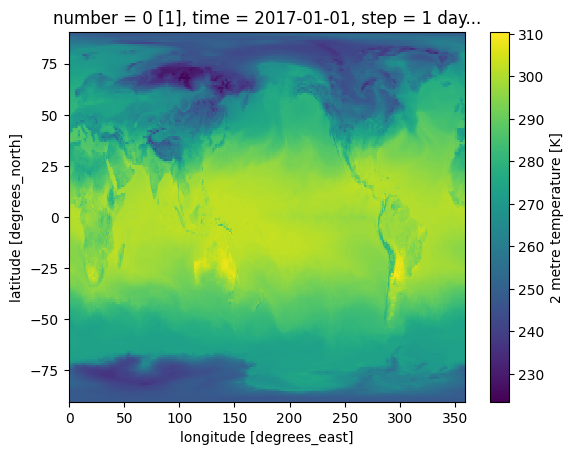

In [8]:
import matplotlib.pyplot as plt

# plot the entire global temperature field
ds['t2m'].plot()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


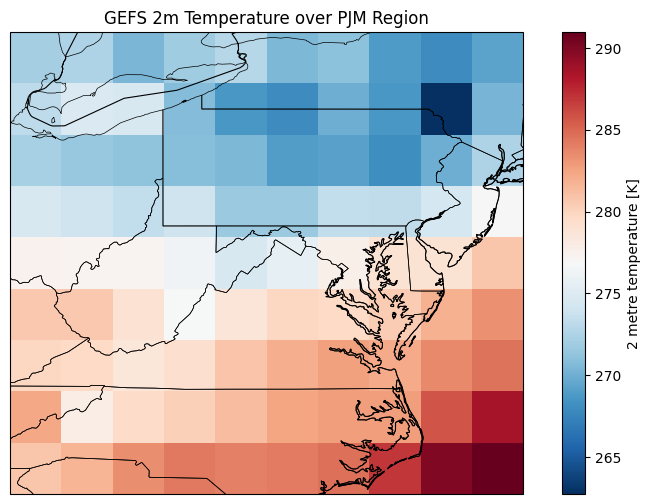

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# subset to PJM first
pjm = ds.sel(
    latitude=slice(43, 35),
    longitude=slice(277, 286)
)

# plot
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# plot the temperature data
pjm['t2m'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'
)

# add geographic features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

plt.title('GEFS 2m Temperature over PJM Region')
plt.show()

(181, 360)
(9, 10)


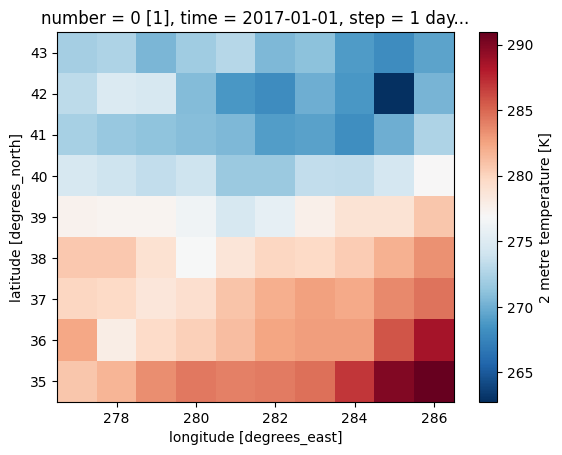

[[272.12 272.54 270.39 271.8  272.8  270.49 271.07 268.89 267.99 269.28]
 [273.18 274.82 274.54 270.74 268.65 267.95 269.93 268.69 262.76 270.27]
 [272.17 271.56 271.22 270.88 270.52 268.94 269.24 268.14 270.01 272.56]
 [274.52 273.98 273.41 273.97 271.62 271.62 273.42 273.25 274.39 276.95]
 [277.52 277.2  277.22 276.26 274.49 275.58 277.66 278.94 278.86 280.81]
 [280.62 280.61 279.04 276.75 278.66 279.87 279.7  280.48 281.87 283.25]
 [279.92 279.68 278.57 279.19 280.83 281.93 282.65 282.15 283.61 284.52]
 [282.29 277.95 279.56 280.18 281.18 282.43 282.8  282.74 285.73 288.54]
 [280.79 281.68 283.43 284.25 284.02 284.17 284.62 286.94 289.86 290.96]]


In [14]:
print(ds["t2m"].shape)
pjm = ds.sel(
    latitude=slice(43, 35),    # note: high to low because latitude is decreasing
    longitude=slice(277, 286)
)

print(pjm["t2m"].shape)
pjm['t2m'].plot(cmap='RdBu_r')
plt.show()

# Step 4: extract as numpy array
temps = pjm['t2m'].values
print(temps) 

In [16]:
member_temps = []

for i in range(31):
    try:
        H = Herbie('2017-01-01 00:00', model='gefs', member=i, fxx=24)
        ds = H.xarray("TMP:2 m")
        pjm = ds.sel(
            latitude=slice(43, 35),
            longitude=slice(277, 286)
        )
        member_temps.append(pjm['t2m'].values)
    except Exception as e:
        print(f"Member {i} failed, skipping")
        continue

print(f"Successfully pulled {len(member_temps)} members")

✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2017-Jan-

In [17]:
print(member_temps)

[array([[272.12, 272.54, 270.39, 271.8 , 272.8 , 270.49, 271.07, 268.89,
        267.99, 269.28],
       [273.18, 274.82, 274.54, 270.74, 268.65, 267.95, 269.93, 268.69,
        262.76, 270.27],
       [272.17, 271.56, 271.22, 270.88, 270.52, 268.94, 269.24, 268.14,
        270.01, 272.56],
       [274.52, 273.98, 273.41, 273.97, 271.62, 271.62, 273.42, 273.25,
        274.39, 276.95],
       [277.52, 277.2 , 277.22, 276.26, 274.49, 275.58, 277.66, 278.94,
        278.86, 280.81],
       [280.62, 280.61, 279.04, 276.75, 278.66, 279.87, 279.7 , 280.48,
        281.87, 283.25],
       [279.92, 279.68, 278.57, 279.19, 280.83, 281.93, 282.65, 282.15,
        283.61, 284.52],
       [282.29, 277.95, 279.56, 280.18, 281.18, 282.43, 282.8 , 282.74,
        285.73, 288.54],
       [280.79, 281.68, 283.43, 284.25, 284.02, 284.17, 284.62, 286.94,
        289.86, 290.96]], dtype=float32), array([[272.18, 272.52, 270.43, 271.84, 272.72, 270.48, 271.1 , 268.99,
        267.44, 268.99],
       [273.

In [18]:
import numpy as np

members_stacked=np.stack(member_temps, axis=0)
print(members_stacked)



[[[272.12 272.54 270.39 ... 268.89 267.99 269.28]
  [273.18 274.82 274.54 ... 268.69 262.76 270.27]
  [272.17 271.56 271.22 ... 268.14 270.01 272.56]
  ...
  [279.92 279.68 278.57 ... 282.15 283.61 284.52]
  [282.29 277.95 279.56 ... 282.74 285.73 288.54]
  [280.79 281.68 283.43 ... 286.94 289.86 290.96]]

 [[272.18 272.52 270.43 ... 268.99 267.44 268.99]
  [273.14 274.81 274.55 ... 268.54 263.35 270.24]
  [272.1  271.43 271.14 ... 268.18 269.9  272.44]
  ...
  [281.03 280.08 278.51 ... 282.13 283.62 284.56]
  [282.74 278.26 279.48 ... 282.75 285.42 288.39]
  [280.78 281.93 282.99 ... 286.06 289.02 290.88]]

 [[272.1  272.53 270.27 ... 268.75 267.32 269.01]
  [272.33 274.45 274.47 ... 268.62 264.09 270.33]
  [272.06 271.41 271.1  ... 268.15 270.44 272.61]
  ...
  [280.52 280.19 278.82 ... 282.33 283.75 284.69]
  [281.91 277.87 279.27 ... 282.52 285.79 288.89]
  [280.95 281.66 283.68 ... 287.18 290.13 291.14]]

 ...

 [[271.89 272.37 270.11 ... 268.69 266.34 268.34]
  [272.88 274.6  274

In [20]:
spread=members_stacked.std(axis=0)
print(spread)

[[0.12975894 0.05661577 0.13641661 0.09474058 0.15576403 0.12241097
  0.08664589 0.15241589 0.3595694  0.2513493 ]
 [0.29074523 0.10221919 0.07054859 0.13778538 0.12405428 0.12560253
  0.08609643 0.30678582 0.65183455 0.05818287]
 [0.14384542 0.14413251 0.12881278 0.13820584 0.3613389  0.46328878
  0.242505   0.13005891 0.24387513 0.17572743]
 [0.33147952 0.46613845 0.35861766 0.30572486 0.22578192 0.2618479
  0.3335489  0.25706506 0.21755406 0.20495173]
 [0.6140361  0.65433836 0.49886486 0.42458642 0.29536298 0.25402457
  0.29713377 0.31623274 0.3319723  0.3066039 ]
 [0.31495216 0.28073823 0.29579517 0.37811077 0.26026884 0.48832354
  0.42380157 0.2202696  0.13212307 0.20368855]
 [0.36853835 0.25105023 0.24224453 0.2750355  0.29601046 0.24099773
  0.30891022 0.24802756 0.19643217 0.150268  ]
 [0.420692   0.3375133  0.24929608 0.28248295 0.2717785  0.2646247
  0.25490716 0.19024234 0.33975336 0.46187836]
 [0.24214096 0.3898538  0.642852   0.7193107  0.68445873 0.4787912
  0.43115076 0.

In [21]:
daily_spread=spread.mean()
print(daily_spread)


0.29214042


In [22]:
def getDaiilySpread(date_time):
    member_temps = []

    for i in range(31):
        try:
            H = Herbie(date_time, model='gefs', member=i, fxx=24)
            ds = H.xarray("TMP:2 m")
            pjm = ds.sel(
                latitude=slice(43, 35),
                longitude=slice(277, 286)
            )
            member_temps.append(pjm['t2m'].values)
        except Exception as e:
            print(f"Member {i} failed, skipping")
            continue
    print(f"Successfully pulled {len(member_temps)} members")
    members_stacked=np.stack(member_temps, axis=0)
    spread=members_stacked.std(axis=0)
    daily_spread=spread.mean()
    return daily_spread
print(getDaiilySpread('2019-01-29 00:00'))

✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2019-Jan-29 00:00 UTC F24 ┊ G

In [50]:
def getDailySpread(date_time,fxx):
    member_temps = []

    for i in range(31):
        try:
            H = Herbie(date_time, model='gefs', member=i, fxx=fxx, save_dir='/tmp')
            ds = H.xarray("TMP:2 m")
            pjm = ds.sel(
                latitude=slice(43, 35),
                longitude=slice(277, 286)
            )
            member_temps.append(pjm['t2m'].values)
        except Exception as e:
            print(f"Member {i} failed, skipping")
            continue
    print(f"Successfully pulled {len(member_temps)} members")
    mean_temp_map = members_stacked.mean(axis=0)
    mean_temp = mean_temp_map.mean()
    members_stacked=np.stack(member_temps, axis=0)
    spread=members_stacked.std(axis=0)
    daily_spread=spread.mean()
    return daily_spread, mean_temp
print(getDailySpread('2019-01-29 00:00', 168))

Member 0 failed, skipping
Member 1 failed, skipping
Member 2 failed, skipping
Member 3 failed, skipping
Member 4 failed, skipping
Member 5 failed, skipping
Member 6 failed, skipping
Member 7 failed, skipping
Member 8 failed, skipping
Member 9 failed, skipping
Member 10 failed, skipping
Member 11 failed, skipping
Member 12 failed, skipping
Member 13 failed, skipping
Member 14 failed, skipping
Member 15 failed, skipping
Member 16 failed, skipping
Member 17 failed, skipping
Member 18 failed, skipping
Member 19 failed, skipping
Member 20 failed, skipping
Member 21 failed, skipping
Member 22 failed, skipping
Member 23 failed, skipping
Member 24 failed, skipping
Member 25 failed, skipping
Member 26 failed, skipping
Member 27 failed, skipping
Member 28 failed, skipping
Member 29 failed, skipping
Member 30 failed, skipping
Successfully pulled 0 members


UnboundLocalError: cannot access local variable 'members_stacked' where it is not associated with a value

Now making get_target_date_features()

In [49]:
import sys
sys.path.append('/Users/adamzachry/Desktop/Cornell/Research/Personal/pjm_weather_ensemble')
import config
import importlib
importlib.reload(config)
from datetime import datetime, timedelta
def get_target_date_features(target_date_str):
    """
    For a single target date T, pulls all 7 forecasts that describe T
    (from 7 different initialization dates at 7 different lead times),
    and computes the forecast evolution signal.
    """
    target_date = datetime.strptime(target_date_str, '%Y-%m-%d %H:%M')
    results = {}
    for fxx in config.fxx_list:
         init_date = target_date - timedelta(hours=fxx)
         init_date_str = init_date.strftime('%Y-%m-%d %H:%M')
         daily_spread, mean_temp = getDailySpread(init_date_str, fxx)
         results['spread_{fxx}'] = daily_spread
         results['temp_{fxx}'] = mean_temp

    if results['temp_168'] is not None and results['temp_24'] is not None:
         forecast_shift = abs(results['temp_168'] - results['temp_24'])
    else:
         forecast_shift = None
    results['forecast_shift'] = forecast_shift

    n_valid = 0
    for fxx in config.fxx_list:
        if results['spread_{fxx}'] != None:
            n_valid += 1
    results['n_valid_leads'] = n_valid

    return results
print(get_target_date_features("2021-06-14 00:00"))


NameError: name 'getDailySpread' is not defined

dict practice

In [ ]:
date_features = {
    'spread_24': np.float32(0.65737766), 'temp_24': np.float32(295.2729), 'spread_48': np.float32(0.8096439), 'temp_48': np.float32(295.44354), 'spread_72': np.float32(1.1391635), 'temp_72': np.float32(295.47604), 'spread_96': np.float32(1.3982097), 'temp_96': np.float32(294.90567), 'spread_120': np.float32(1.7905709), 'temp_120': np.float32(295.54608), 'spread_144': np.float32(1.9394563), 'temp_144': np.float32(294.17172), 'spread_168': np.float32(2.4509392), 'temp_168': np.float32(295.41238), 'forecast_shift': np.float32(0.13949585), 'n_valid_leads': 7
}
trajectory_features = {
    'trajectory_vol': 0.034,
    'path_length': 12.3,
    'near_term_shift': 0.67,
    'far_term_shift': 6.7
}


In [5]:
import pandas as pd
import numpy as np
def fetch_lmp_year(year):
    """
    
    """
    year_csv = pd.read_csv(f"https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_rt_hr_zones_{year}.csv", skiprows=3)
    year_csv = year_csv[['Local Date', 'Hour Number', 'PJM Total LMP']]
    year_csv.columns = ['date', 'hour', 'lmp']
    return year_csv

df = fetch_lmp_year(2021)
print(df.groupby('date').size().value_counts())

24    363
23      1
25      1
Name: count, dtype: int64


In [10]:

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def fetch_lmp_year(year):
    """
    Returns Local Date, Hour Number and PJM Total LMP for specified year, with columns renamed to date, hour, lmp respectively
    year : int, 2020<=year<=2025
    """
    year_csv = pd.read_csv(f"https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_rt_hr_zones_{year}.csv", skiprows=3)
    year_csv = year_csv[['Local Date', 'Hour Number', 'PJM Total LMP']]
    year_csv.columns = ['date', 'hour', 'lmp']
    return year_csv

def daily_metrics(group):
    """
    
    """
    prices = group['lmp']
    daily_mean = prices.mean()
    upside = prices[prices > daily_mean]
    return pd.Series({
        'realized_vol': prices.std(),
        'mean_price': daily_mean,
        'price_range': prices.max() - prices.min(),
        'upside_variance': upside.std() if len(upside) > 0 else 0.0,
        'spike_100': int((prices > 100).any()),
        'spike_200': int((prices > 200).any()),
        'spike_500': int((prices > 500).any()),
        'hour_count': len(prices)
    })

def compute_daily_metrics(hourly_df):
    """
    
    """
    return hourly_df.groupby('date').apply(daily_metrics, include_groups=False).reset_index()

def build_lmp_dataset(start_year, end_year):
    """
    
    """
    all_years = []
    for year in range(start_year, end_year + 1):
        print(f"Fetching {year}...")
        hourly = fetch_lmp_year(year)
        daily = compute_daily_metrics(hourly)
        all_years.append(daily)

    df = pd.concat(all_years, ignore_index=True)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # drop DST days (23 or 25 hours) — only 2 per year, keeps metrics comparable
    df = df[df['hour_count'] == 24]

    # filter to match weather dataset range
    df = df[(df['date'] >= '2020-09-23') & (df['date'] <= '2025-12-31')]

    df.to_csv('data/processed/lmp_daily.csv', index=False)
    print(f"Saved {len(df)} rows")
    return df

df2024 = fetch_lmp_year(2024)
daily2024 = compute_daily_metrics(df2024)
# check the max realized_vol day of the year
print(daily2024.nlargest(10, 'realized_vol')[['date', 'realized_vol', 'mean_price', 'spike_100', 'spike_500']])

           date  realized_vol  mean_price  spike_100  spike_500
45   2024-03-10     89.845731   38.653285        1.0        0.0
173  2024-07-16     87.117884   80.631634        1.0        0.0
117  2024-05-21     85.398196   74.497574        1.0        0.0
314  2024-12-04     76.822754   76.946611        1.0        0.0
18   2024-01-22     73.942081   65.869838        1.0        0.0
165  2024-07-08     65.460564   71.944419        1.0        0.0
16   2024-01-20     64.309385   63.010389        1.0        0.0
156  2024-06-29     61.162428   65.393959        1.0        0.0
185  2024-07-28     60.593754   39.283989        1.0        0.0
166  2024-07-09     57.583219   77.102531        1.0        0.0
